## 数据预处理

### 数据读取

In [1]:
from struct import unpack
import numpy as np
import os
def read_dat(datafile:str)->dict:
    """
    读取原始回波数据。以帧信息序列返回。
    
    
    参数:
        datafile: 原始回波数据.dat文件
    
    返回:
        frames: 帧字典，每个元素为一帧:
            '航迹点序号':
            {'方位角': float,
             '目标数量': int,
             '目标信息': {'批号': int,
                         '航迹点序号': int,
                         '幅度最大距离单元': int,
                         '幅度最大多普勒单元': int,
                        },
             '频率': float,
             'CPI流水号': int,
             'PRT数量': int,
             'PRT时间': float,
             '距离单元数': int,
             'IQ数据': np.ndarray <size = (31, PRT数量)>
            }
    """
    frames = {}
    file_size = os.stat(datafile).st_size
    with open(datafile, 'rb') as f:
        frame = {}
        while f.tell() < file_size:
            # 帧头
            head = ''
            while head != 0xFA55FA55:
                head = unpack('<I',f.read(4))[0]
            # 帧长度
            length = unpack('<I',f.read(4))[0]
            # 方位角(°)
            frame['方位角'] = unpack('<I',f.read(4))[0] * 0.01
            # 目标数量
            pointNum_in_bowei = unpack('<I',f.read(4))[0]
            frame['目标数量'] = pointNum_in_bowei
            # 目标信息
            Track_No_info = []
            for _ in range(pointNum_in_bowei):
                # 批号
                batch_no = unpack('<I',f.read(4))[0]
                # 航迹点序号
                track_no = unpack('<I',f.read(4))[0]
                # 幅度最大距离单元
                max_amp_unit = unpack('<I',f.read(4))[0]
                # 幅度最大多普勒单元
                max_amp_dop_unit = unpack('<I',f.read(4))[0]

                Track_No_info.append({'批号':batch_no, '航迹点序号':track_no, '幅度最大距离单元':max_amp_unit, '幅度最大多普勒单元':max_amp_dop_unit})
            frame['目标信息'] = Track_No_info
            # 频率(Hz)
            frame['频率'] = unpack('<I',f.read(4))[0] * 1e6
            # CPI流水号
            frame['CPI流水号'] = unpack('<I',f.read(4))[0]
            # PRT数量
            PRTnum = unpack('<I',f.read(4))[0]
            frame['PRT数量'] = PRTnum
            # PRT时间(s)
            frame['PRT时间'] = unpack('<I',f.read(4))[0] * 0.0125e-6
            # 距离单元数
            frame['距离单元数'] = unpack('<I',f.read(4))[0]
            # IQ数据
            IQdata = []
            for _ in range(31):
                row = []
                for _ in range(PRTnum):
                    I,Q = unpack('<2f', f.read(8))
                    row.append(complex(I,Q))
                IQdata.append(row)
            frame['IQ数据'] = np.array(IQdata)
            # 帧尾
            tail = unpack('<I',f.read(4))[0]
            if tail != 0x55FA55FA:
                print(f"第{len(frames)+1}帧尾核验失败")
                break

            if not track_no in frames.keys():
                frames[track_no] = [frame.copy()]
            else:
                frames[track_no].append(frame.copy())
    return frames

In [ ]:
# 加载数据
import os
# path = 'D:\\A_files\\challenge_cup\\project\\原始回波'
# 获取当前脚本文件所在目录
# current_dir = os.getcwd()
# 构造相对路径
path ="dataset/原始回波"
path = os.path.abspath(path)
datafile = os.path.join(path,'276_Label_2.dat')
print(datafile)

# 采样率
Fs = 20e6
# 采样分辨率
delta_R = 3e8/2/Fs

frames = read_dat(datafile)

for no, groups in frames.items():
    for frame in groups:
        print(no, frame['目标信息'])

d:\A_files\project\原始回波\276_Label_2.dat


FileNotFoundError: [WinError 3] 系统找不到指定的路径。: 'd:\\A_files\\project\\原始回波\\276_Label_2.dat'

### FFT变换获得RD图

In [ ]:
import numpy as np
from scipy.signal.windows import taylor
import matplotlib.pyplot as plt
import warnings
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")

def process_radar_frame(frame, delta_R):
    """
    处理雷达单帧数据，执行MTD处理和目标检测
    
    参数:
        para: 雷达参数字典
        data_out: 原始IQ数据矩阵 (31 × PRT_num)
        delta_R: 距离分辨率 (米/距离单元)
    
    返回:
        data_proc_MTD_result: MTD处理结果 (距离-多普勒图)
        Amp_max_range: 检测目标距离 (米)
        Amp_max_Vr: 检测目标速度 (米/秒)
        Vr: 速度轴数组
        Range_plot: 距离轴数组
    """
    # 1. MTD处理 (动目标显示)
    data_out = frame['IQ数据']
    n_pulses = data_out.shape[1]  # 脉冲数量
    
    # 生成泰勒窗
    taylor_window = taylor(n_pulses, sll=30)
    
    # 创建2D窗矩阵 (匹配数据维度)
    window_2d = np.tile(taylor_window, (data_out.shape[0], 1))
    
    # 加窗处理
    data_windowed = data_out * window_2d
    
    # 沿脉冲维度进行FFT (多普勒处理)
    data_fft = np.fft.fft(data_windowed, axis=1)
    
    # 频谱中心化
    data_proc_MTD_result = np.fft.fftshift(data_fft, axes=1)
    
    # 2. 计算速度轴
    c = 3e8  # 光速 (m/s)
    delta_Vr = c / (2 * n_pulses * frame['PRT时间'] * frame['频率'])
    Vr = np.linspace(-n_pulses/2, n_pulses/2 - 1, n_pulses) * delta_Vr
    
    # 3. 目标检测
    # 获取目标信息 (假设每帧只有一个目标)
    track_info = frame['目标信息'][0]
    if len(track_info) < 4:
        print("警告：目标信息不完整")
        return None, None, None, None, None
    
    # 解析目标信息 [批号, 航迹点序号, 距离单元, 多普勒单元]
    target_range_bin = track_info['幅度最大距离单元']   # 距离单元索引
    target_doppler_bin = track_info['幅度最大多普勒单元']  # 多普勒单元索引
    
    # 调整多普勒单元索引 (考虑fftshift)
    n_doppler_bins = data_proc_MTD_result.shape[1]
    if target_doppler_bin > n_doppler_bins / 2:
        adjusted_doppler_bin = target_doppler_bin - n_doppler_bins // 2
    else:
        adjusted_doppler_bin = target_doppler_bin + n_doppler_bins // 2
    
    # 设置局部检测窗口 (5×5)
    center_local_bin = 16  # 中心距离单元 (第16个)
    local_radius = 5
    
    # 计算检测窗口边界
    range_start = max(0, center_local_bin - local_radius)
    range_end = min(data_proc_MTD_result.shape[0], center_local_bin + local_radius)
    doppler_start = max(0, int(adjusted_doppler_bin) - local_radius)
    doppler_end = min(data_proc_MTD_result.shape[1], int(adjusted_doppler_bin) + local_radius)
    
    # 提取检测窗口数据
    detection_window = data_proc_MTD_result[range_start:range_end, doppler_start:doppler_end]
    
    # 寻找峰值位置
    max_val = np.max(np.abs(detection_window))
    max_pos = np.where(np.abs(detection_window) == max_val)
    
    # 获取局部窗口内的行列索引
    if len(max_pos[0]) > 0:
        local_row = max_pos[0][0]
        local_col = max_pos[1][0]
    else:
        print("警告：未检测到峰值")
        return data_proc_MTD_result, None, None, Vr, None
    
    # 4. 计算实际距离和速度
    # 计算距离轴
    range_start_bin = target_range_bin - 15
    range_end_bin = target_range_bin + 15
    range_bins = np.arange(range_start_bin, range_end_bin + 1)
    Range_plot = range_bins * delta_R
    
    # 转换到全局距离位置
    global_range_bin = range_start + local_row
    Amp_max_range = Range_plot[global_range_bin]
    
    # 转换到全局速度位置
    global_doppler_bin = doppler_start + local_col
    Amp_max_Vr = Vr[global_doppler_bin]
    
    return data_proc_MTD_result, Amp_max_range, Amp_max_Vr, Vr, Range_plot

def visualize_results(data_proc_MTD_result, Vr, Range_plot, 
                      target_range, target_velocity):
    """
    可视化MTD处理结果
    
    参数:
        data_proc_MTD_result: MTD处理结果
        Vr: 速度轴
        Range_plot: 距离轴
        target_range: 目标距离
        target_velocity: 目标速度
    """
    plt.figure(figsize=(8, 6))
    
    # 绘制距离-多普勒图
    plt.imshow(20 * np.log10(np.abs(data_proc_MTD_result)), 
               aspect='auto', 
               cmap='viridis',
               extent=[Vr.min(), Vr.max(), Range_plot.max(), Range_plot.min()])
    plt.colorbar(label='强度 (dB)')
    plt.scatter(target_velocity, target_range, c='red', s=50, marker='x')
    plt.xlim(-30,30)
    plt.xlabel('速度 (m/s)')
    plt.ylabel('距离 (m)')
    plt.title('距离-多普勒图')
    plt.gca().invert_yaxis()  # 反转Y轴使距离向下增加
    
    plt.tight_layout()
    plt.show()
    
    # 打印目标信息
    print(f"检测目标 - 距离: {target_range:.1f}m, 速度: {target_velocity:.2f}m/s")

(31, 226)


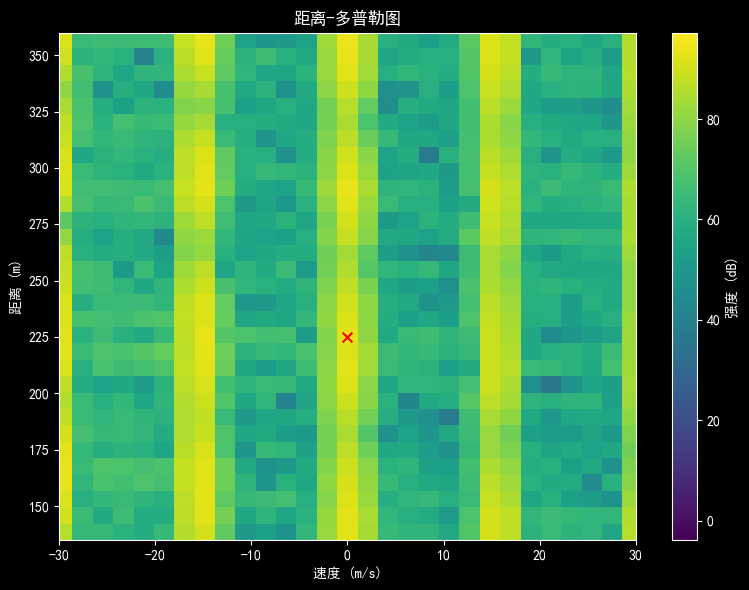

检测目标 - 距离: 225.0m, 速度: 0.00m/s


In [ ]:
first_key = next(iter(frames))   # 取第一个键
first_frame = frames[first_key][0]  # 该键对应的列表的第一个元素

# 处理单帧数据
# mtd_result, target_range, target_velocity, Vr, Range_plot = process_radar_frame(frames[0], delta_R)
mtd_result, target_range, target_velocity, Vr, Range_plot = process_radar_frame(first_frame, delta_R)
print(mtd_result.shape)
# 可视化结果
if mtd_result is not None:
    visualize_results(mtd_result, Vr, Range_plot, target_range, target_velocity)

### ZAM变换获取时频图

In [ ]:
import numpy as np
from scipy.signal import get_window
from scipy.fft import fftshift, fft2, ifft2

def zam_transform(signal_matrix, fs, g_window='hann', a=1.0):
    """
    对雷达回波数据矩阵应用ZAM变换
    
    参数:
        signal_matrix: 复数矩阵 (距离单元 × 脉冲重复周期)
        fs: 采样频率 (Hz)
        g_window: 窗函数类型 (默认为泰勒窗)
        a: sinc函数的缩放参数 (默认为1.0)
    
    返回:
        zam_tfr: ZAM变换结果 (频率 × 时间)
        time_axis: 时间轴
        freq_axis: 频率轴
    """
    # 获取矩阵尺寸
    n_range_bins, n_pulses = signal_matrix.shape
    
    # 创建时间和频率轴
    time_axis = np.arange(n_pulses) / fs
    freq_axis = np.linspace(-fs/2, fs/2, n_pulses)
    
    # 初始化ZAM变换结果矩阵
    zam_tfr = np.zeros((n_pulses, n_pulses), dtype=complex)
    
    # 创建窗函数
    g_tau = get_window(g_window, n_pulses)
    g_tau = g_tau * np.abs(np.arange(-n_pulses//2, n_pulses//2))
    
    # 遍历每个距离单元
    for r in range(n_range_bins):
        signal = signal_matrix[r, :]
        
        # 计算模糊函数
        ambiguity = np.zeros((n_pulses, n_pulses), dtype=complex)
        for tau in range(-n_pulses//2, n_pulses//2):
            u_indices = np.arange(max(0, -tau), min(n_pulses, n_pulses - tau))
            s1 = signal[u_indices + tau]
            s2 = np.conj(signal[u_indices])
            ambiguity[tau + n_pulses//2, u_indices] = s1 * s2
        
        # 计算核函数
        theta = np.linspace(-1, 1, n_pulses)
        tau = np.arange(-n_pulses//2, n_pulses//2) / fs
        theta_grid, tau_grid = np.meshgrid(theta, tau)
        
        # φ(θ,τ) = g(τ)|τ|·sinc(aθτ)
        kernel = g_tau * np.sinc(a * theta_grid * tau_grid)
        
        # 应用核函数
        kernel_ambiguity = kernel * ambiguity
        
        # 计算ZAM变换 (二维傅里叶变换)
        zam_slice = fftshift(fft2(kernel_ambiguity))
        
        # 累积结果
        zam_tfr += np.abs(zam_slice)
    
    # 平均处理
    zam_tfr /= n_range_bins
    
    return zam_tfr, time_axis, freq_axis

def plot_results(data, zam_result, time_axis, freq_axis):
    """可视化原始数据和ZAM变换结果"""
    plt.figure(figsize=(15, 10))
    
    # 原始数据幅度
    plt.subplot(221)
    plt.imshow(np.abs(data), aspect='auto', cmap='viridis',
               extent=[0, time_axis[-1], data.shape[0]-1, 0])
    plt.title('原始数据幅度 (距离单元 vs 时间)')
    plt.xlabel('时间 (s)')
    plt.ylabel('距离单元')
    plt.colorbar()
    
    # 原始数据相位
    plt.subplot(222)
    plt.imshow(np.angle(data), aspect='auto', cmap='hsv',
               extent=[0, time_axis[-1], data.shape[0]-1, 0])
    plt.title('原始数据相位 (距离单元 vs 时间)')
    plt.xlabel('时间 (s)')
    plt.ylabel('距离单元')
    plt.colorbar()
    
    # ZAM变换结果
    plt.subplot(212)
    plt.imshow(np.abs(zam_result), aspect='auto', cmap='hot',
               extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]])
    plt.title('ZAM变换时频图')
    plt.xlabel('时间 (s)')
    plt.ylabel('频率 (Hz)')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

(226, 226)


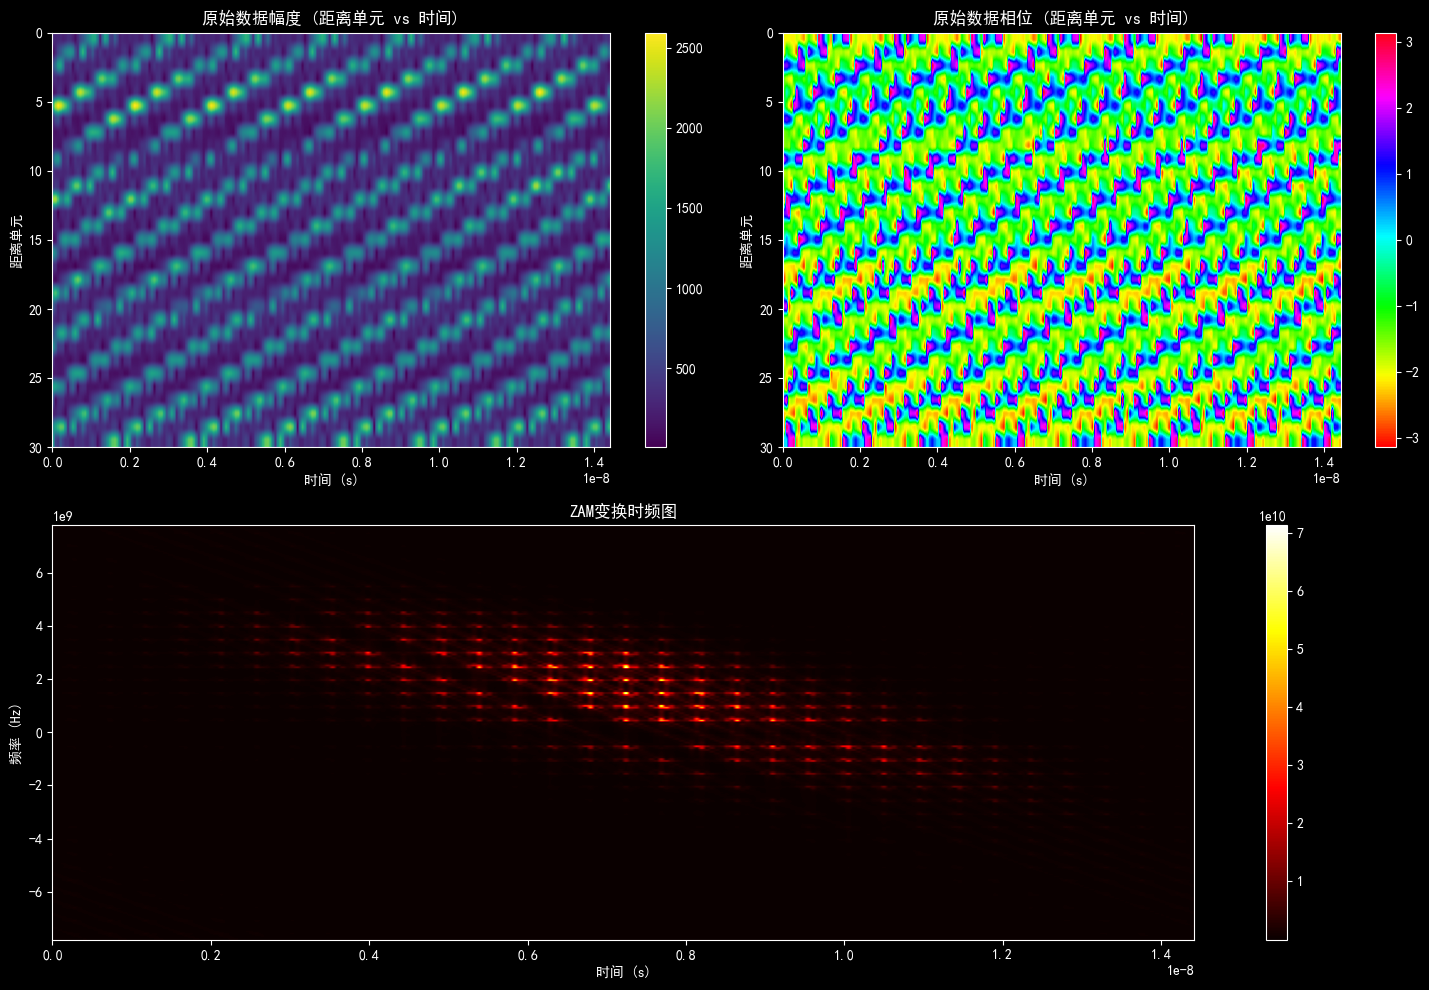

In [ ]:
# k = 0
# data = frames[k]['IQ数据']
# fs = frames[k]['频率']
k = 0
first_key = next(iter(frames))   # 取第一个键
first_frame = frames[first_key][k]  # 该键对应的列表的第k个元素
data = first_frame['IQ数据']
fs = first_frame['频率']

data = data - np.mean(data, axis=1, keepdims=True)
#window = np.hanning(data.shape[1])
#data = data * window[np.newaxis, :]
zam_result, time_axis, freq_axis = zam_transform(data, fs, g_window='hamming', a=0.5)
print(zam_result.shape)
plot_results(data, zam_result, time_axis, freq_axis)

In [ ]:
20 * np.log10(np.abs(mtd_result))

array([[22.72056598, 24.25932639, 25.76180899, ..., 37.60256601,
        22.26891251, 35.73310591],
       [38.42081688, 39.83907361, 41.96611949, ..., 49.08443946,
        36.18575482, 43.27587896],
       [41.11445939, 41.81229163, 39.9744491 , ..., 53.89556421,
        35.89656313, 44.41155153],
       ...,
       [41.85980754, 37.90928927, 38.07061769, ..., 44.27887753,
        37.56761282, 40.06267483],
       [49.64076837, 50.39618335, 50.17679668, ..., 53.94143448,
        49.06470051, 51.20894942],
       [48.50585861, 47.67686409, 48.3022163 , ..., 54.8867446 ,
        48.57055086, 48.30324868]])

### 构建数据集

In [ ]:
import shutil
import os
def build_dataset_RAW(raw_datas_path:str, dataset_path:str, num_classes:int = 4)->bool:
    """
    采用原始雷达回波数据作为数据集。
    
    参数：
    raw_datas_path: 原始数据文件夹
    dataset_path: 数据集存储文件夹
    classes: 分类数，默认为6，小于6时所有label>classes的类别均标记为classes
    """
    if not os.path.exists(raw_datas_path):
        print(f"原始数据文件夹 {raw_datas_path} 不存在")
        return False
    if os.path.exists(dataset_path):
        shutil.rmtree(dataset_path)
    os.mkdir(dataset_path)
    for label_file in os.listdir(raw_datas_path):
        label_datas_path = os.path.join(raw_datas_path, label_file, '原始回波')
        for dat_file in os.listdir(label_datas_path):
            name, _ = os.path.splitext(dat_file)
            CPI_no, _, label = name.split('_')
            label = str(num_classes) if int(label) > num_classes else label
            dat_path = os.path.join(label_datas_path, dat_file)
            all_frames = read_dat(dat_path)
            for track_no, frames  in all_frames.items():
                k = 1
                for frame in frames:
                    npys_path = os.path.join(dataset_path, f'{label}_{CPI_no}_{track_no}')
                    if not os.path.exists(npys_path):
                        os.mkdir(npys_path)
                    data_file = os.path.join(npys_path, f'{k}.npy')
                    k += 1
                    np.save(data_file, frame['IQ数据'])
    print('数据集构建完成（构建方式: 原始回波数据）')
    print(f'数据集已存储至{dataset_path}')
    return True

## 模型

### 导入数据集

In [ ]:
import torch
from torch.utils.data import Dataset

class ComplexVariableWidthDataset(Dataset):
    def __init__(self, sequences, labels):
        """
        sequences: 列表的列表，外层是样本，内层是时间步张量
                  每个时间步张量形状为 (31, width)
        labels: 样本标签列表
        """
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def complex_variable_collate_fn(batch):
    """
    处理不同时间步宽度变化的批次
    """
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    return sequences, lengths, labels

In [ ]:
import os
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
def load_dataset(dataset_path, test_size = 0.2):
    """
    从数据集文件夹中加载数据集
    
    参数:
    dataset_path: 数据集文件夹
    test_size: 测试集占比

    返回:
    dataloader: 训练集数据加载器
    train_sequences: 训练集数据
    test_sequences: 测试集数据
    train_labels: 训练集标签
    test_labels: 测试集标签
    """
    sequences = []
    labels = []
    for npys_file in os.listdir(dataset_path):
        label, _, _ = npys_file.split('_')
        npys_path = os.path.join(dataset_path, npys_file)
        data = []
        for k in range(1,51):
            npy_file = os.path.join(npys_path, f'{k}.npy')
            if os.path.exists(npy_file):
                data.append(torch.tensor(np.load(npy_file)))
            else:
                break
        sequences.append(data)
        labels.append(int(label)-1)
    # 分割训练集和测试集
    train_sequences, test_sequences, train_labels, test_labels = train_test_split(sequences, labels, test_size = test_size)
    dataset = ComplexVariableWidthDataset(train_sequences, train_labels)
    dataloader = DataLoader(
        dataset, 
        batch_size=2, 
        shuffle=True, 
        collate_fn=complex_variable_collate_fn
    )
    return dataloader, train_sequences, test_sequences, train_labels, test_labels

### 原始回波数据CNN+RNN微时序处理模型

#### 模型结构

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Tuple

class ComplexVariableWidthCNNRNN(nn.Module):
    def __init__(self, num_classes, cnn_channels=16, lstm_hidden=64):
        super().__init__()
        
        # 复数处理层 - 分离实部和虚部
        self.conv1_real = nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1)
        self.conv1_imag = nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1)
        
        self.conv2_real = nn.Conv2d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1)
        self.conv2_imag = nn.Conv2d(cnn_channels, cnn_channels*2, kernel_size=3, padding=1)
        
        # 自适应池化处理不同尺寸
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # 复数特征融合层
        self.complex_fusion = nn.Sequential(
            nn.Linear(cnn_channels*2 * 4, cnn_channels*2 * 2),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # 处理时序的RNN
        self.rnn = nn.LSTM(
            input_size=cnn_channels*2 * 2,
            hidden_size=lstm_hidden, 
            batch_first=True,
            bidirectional=True
        )
        
        # 分类头
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(lstm_hidden*2, num_classes)
        )
    
    def process_time_step(self, x: torch.Tensor) -> torch.Tensor:
        """
        处理单个时间步的复数张量，适应不同宽度
        x: 复数张量，形状 (height, width)
        """
        # 确保输入是正确类型 (complex64 或 complex128)
        if x.dtype not in (torch.complex64, torch.complex128):
            # 如果是实部虚部分开的张量，转换为复数
            if isinstance(x, tuple) and len(x) == 2:
                x = torch.complex(x[0], x[1])
            else:
                raise ValueError("输入必须是复数张量或(实部,虚部)元组")
        
        # 确保输入有正确的维度 (1, height, width)
        if x.dim() == 2:
            x = x.unsqueeze(0)  # 添加通道维度
        
        # 类型转换：确保使用32位浮点数
        if x.dtype == torch.complex128:
            x = x.to(torch.complex64)
        
        # 分离实部和虚部
        real_part = x.real.float()  # 转换为float32
        imag_part = x.imag.float()  # 转换为float32
        
        # 通过各自的卷积路径
        real_feat = F.relu(self.conv1_real(real_part))
        imag_feat = F.relu(self.conv1_imag(imag_part))
        
        real_feat = F.relu(self.conv2_real(real_feat))
        imag_feat = F.relu(self.conv2_imag(imag_feat))
        
        # 自适应池化
        real_feat = self.pool(real_feat).squeeze(-1).squeeze(-1)
        imag_feat = self.pool(imag_feat).squeeze(-1).squeeze(-1)
        
        # 组合复数特征
        complex_feat = torch.cat([
            real_feat, 
            imag_feat,
            torch.abs(real_feat + 1j * imag_feat),  # 幅度
            torch.angle(real_feat + 1j * imag_feat)  # 相位
        ], dim=-1)
        
        # 通过融合层
        return self.complex_fusion(complex_feat)
    
    def forward(self, sequences: List[List[torch.Tensor]], lengths: torch.Tensor = None):
        """
        处理不同时间步宽度变化的复数序列
        
        Args:
            sequences: 列表的列表，外层列表是批次，内层列表是时间步
                      每个时间步张量形状为 (31, width_t)
            lengths: 每个样本的实际时间步长度
        """
        batch_size = len(sequences)
        
        # 如果没有提供长度，使用序列长度
        if lengths is None:
            lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
        else:
            lengths = lengths.clone().detach().to(torch.long)
        
        # 找到最大时间步数
        max_timesteps = max(lengths).item()
        
        # 存储每个样本的特征序列
        all_features = []
        
        # 处理每个样本
        for i, sample_seq in enumerate(sequences):
            sample_features = []
            num_timesteps = lengths[i].item()
            
            # 处理每个时间步
            for t in range(num_timesteps):
                # 获取当前时间步的张量
                time_step_tensor = sample_seq[t]
                
                # 处理当前时间步
                features = self.process_time_step(time_step_tensor)
                sample_features.append(features)
            
            # 如果时间步不足，填充零向量
            if num_timesteps < max_timesteps:
                padding = torch.zeros(max_timesteps - num_timesteps, 
                                     self.complex_fusion[0].out_features,
                                     dtype=torch.float32,  # 明确使用float32
                                     device=sample_features[0].device if sample_features else "cpu")
                sample_features.extend(padding)
            
            # 堆叠时间步特征
            sample_features = torch.stack(sample_features, dim=0)
            all_features.append(sample_features)
        
        # 创建批次张量 (batch, timesteps, features)
        rnn_input = torch.stack(all_features, dim=0)
        
        # 打包序列
        packed_input = nn.utils.rnn.pack_padded_sequence(
            rnn_input, 
            lengths.cpu(), 
            batch_first=True, 
            enforce_sorted=False
        )
        
        # RNN处理
        packed_output, (hn, _) = self.rnn(packed_input)
        
        # 提取最后一个有效时间步的输出
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # 获取最后一个有效时间步
        last_idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, output.size(2))
        last_output = output.gather(1, last_idx).squeeze(1)
        
        return self.fc(last_output)

#### 训练

In [ ]:
def train(dataloader, model_path, num_classes = 4, epoches = 10):
    """
    模型训练

    参数:
    dataloader: 存有训练数据的数据加载器
    model_path: 模型保存路径
    num_classes: 类别数，默认为4
    epoches: 训练轮次，默认为10

    返回:
    model: 训练后的模型
    """
    # 初始化模型
    model = ComplexVariableWidthCNNRNN(num_classes=num_classes, cnn_channels=16, lstm_hidden=64)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # 训练设置
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 添加学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    # 训练循环
    for epoch in range(epoches):
        total_loss = 0
        model.train()
        
        for batch_sequences, batch_lengths, batch_labels in dataloader:
            # 将序列数据移动到设备
            batch_sequences = [
                [tensor.to(device) for tensor in seq] 
                for seq in batch_sequences
            ]
            batch_lengths = batch_lengths.to(device)
            batch_labels = batch_labels.to(device)
            
            # 前向传播
            outputs = model(batch_sequences, batch_lengths)
            
            # 计算损失
            loss = criterion(outputs, batch_labels)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            
            # 梯度裁剪防止爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            
            total_loss += loss.item()
        avg_loss = total_loss/len(dataloader)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

        # 更新学习率
        scheduler.step(avg_loss)

    # 保存模型
    torch.save(model.state_dict(), model_path)
    return model

### 模型评估

In [ ]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import torch
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 绘制混淆矩阵
def plot_confusion_matrix(cm, acc, classes = 4, normalize=False, cmap=plt.cm.Blues):
    """
    - cm : 计算出的混淆矩阵的值
    - classes : 混淆矩阵中每一行每一列对应的列
    - normalize : True:显示百分比, False:显示个数
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("显示百分比：")
        np.set_printoptions(formatter={'float': '{: 0.2f}'.format})
        print(cm)
    else:
        print('显示具体数字：')
        print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(f'Confusion matrix\nacc = {acc*100:.2f}%')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.ylim(len(classes) - 0.5, -0.5)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def report(model, test_sequences, test_labels, num_classes=4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    # 模型预测
    with torch.no_grad():
        # 将序列数据移动到设备
        test_sequences_device = [
            [tensor.to(device) for tensor in seq] 
            for seq in test_sequences
        ]
        
        predictions = model(test_sequences_device)
        predicted_classes = predictions.argmax(dim=1)

    # 计算混淆矩阵与准确率
    cm = np.zeros((num_classes,num_classes),dtype=int)
    sum = 0
    for i in range(len(predicted_classes)):
        true = test_labels[i]
        predict = int(predicted_classes[i])
        cm[true][predict] += 1
        if true == predict:
            sum += 1
    acc = sum/len(predicted_classes)
    plot_confusion_matrix(cm, acc, np.arange(1,num_classes+1,1,dtype=int))

## 主函数

In [ ]:
# 项目路径
path = 'dataset'
# 原始数据文件夹
raw_datas_path = os.path.join(path,'data')
# 数据集文件夹
dataset_path = os.path.join(path,'dataset_RAW')
# 模型文件夹
model_path = 'model/complex_variable_width_model.pth'
# 分类任务数
num_classes = 4

文件结构
project/
│
├── data/
│   ├── label1/
│   │   ├── 点迹/
│   │   ├── 航迹/
│   │   └── 原始回波/
│   │       ├── 1_Label_1.dat
│   │       ……
│   │
│   ├── label2/
│   │   └── 点迹/
│   │   └── 航迹/
│   │   └── 原始回波/
│   │       ├── 276_Label_2.dat
│   │       ……
│   ……
│   └── label6/
│
├── dataset_RAW/
│   ├── 1_1_1/(标签_批号_航迹点序号)
│   │   ├── 1.npy(该点第i帧原始回波IQ数据)
│   │   ├── 2.npy
│   │   ……
│   ├── 1_1_2/
│   │   ……
│   ……
│
└── models/
    └── complex_variable_width_model.pth


In [15]:
# 构建数据集
build_dataset_RAW(raw_datas_path, dataset_path, num_classes = num_classes)
# 加载数据集
dataloader, train_sequences, test_sequences, train_labels, test_labels = load_dataset(dataset_path)

数据集构建完成（构建方式: 原始回波数据）
数据集已存储至dataset_RAW


In [16]:
# 模型训练
model = train(dataloader, model_path, num_classes=num_classes, epoches=15)

Epoch 1, Loss: 1.4233
Epoch 2, Loss: 1.2107
Epoch 3, Loss: 0.8326
Epoch 4, Loss: 0.7730
Epoch 5, Loss: 0.7353
Epoch 6, Loss: 0.7236
Epoch 7, Loss: 0.6685
Epoch 8, Loss: 0.6052
Epoch 9, Loss: 0.6215
Epoch 10, Loss: 0.5517
Epoch 11, Loss: 0.4992
Epoch 12, Loss: 0.4935
Epoch 13, Loss: 0.5029
Epoch 14, Loss: 0.4987
Epoch 15, Loss: 0.4917


训练集上测试结果:
显示具体数字：
[[293   2   4  20]
 [  0 254   8   8]
 [  9   0 263  24]
 [  7  13   5 286]]


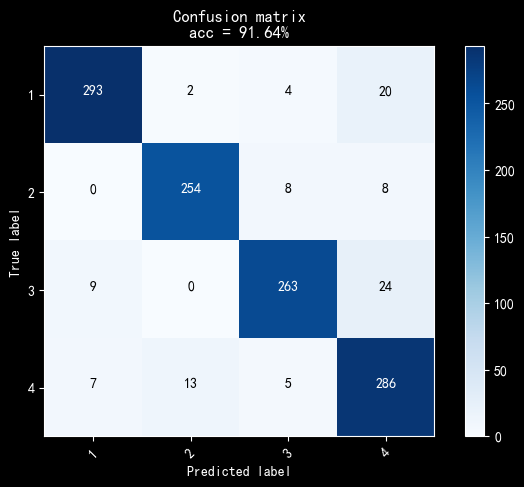

测试集上测试结果:
显示具体数字：
[[62  0  0  7]
 [ 0 59  1  3]
 [ 4  0 83  8]
 [ 1  4  1 66]]


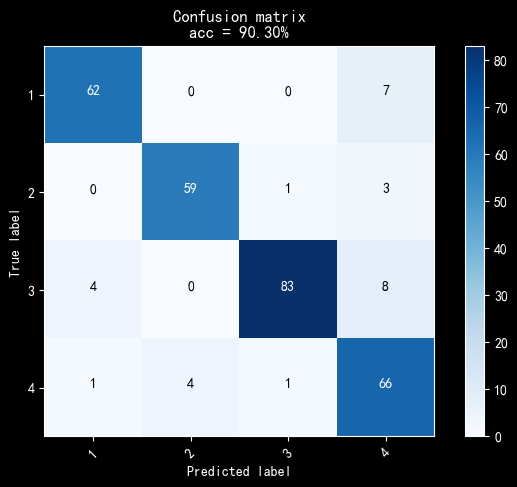

In [17]:
# 模型评估
print('训练集上测试结果:')
report(model, train_sequences, train_labels, num_classes=num_classes)
print('测试集上测试结果:')
report(model, test_sequences, test_labels, num_classes=num_classes)

### mobilenet-v3

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def Hswish(x, inplace=True):
    """
    Hard Swish 激活函数
    公式: x * relu6(x + 3) / 6
    
    参数:
      x: 输入张量
        inplace: 是否原地操作 (节省内存)
    """
    return x * F.relu6(x + 3., inplace=inplace) / 6

def Hsigmoid(x, inplace=True):
    """
    Hard Sigmoid 激活函数
    公式: relu6(x + 3) / 6
    
    参数:
        x: 输入张量
        inplace: 是否原地操作
    """
    return F.relu6(x + 3., inplace=inplace) / 6

class SEModule(nn.Module):
    """
    Squeeze-and-Excitation (SE) 模块
    通过通道注意力机制增强特征表示能力
    
    参数:
        channel: 输入通道数
        reduction: 压缩比率 (默认4)
    """
    def __init__(self, channel, reduction=4):
        super(SEModule, self).__init__()
        # 全局平均池化层 (将任意尺寸输入压缩为1x1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # SE模块的全连接层
        self.se = nn.Sequential(
            # 降维层: channel -> channel//reduction
            nn.Linear(channel, channel // reduction, bias=False),
            # ReLU激活函数
            nn.ReLU(inplace=True),
            # 升维层: channel//reduction -> channel
            nn.Linear(channel // reduction, channel, bias=False),
        )

    def forward(self, x):
        # 获取输入张量的维度信息
        b, c, _, _ = x.size()
        
        # 1. Squeeze: 全局平均池化 (b,c,h,w) -> (b,c)
        y = self.avg_pool(x).view(b, c)
        
        # 2. Excitation: 通过全连接层学习通道权重 (b,c) -> (b,c)
        y = self.se(y)
        
        # 3. 应用Hard Sigmoid激活并重塑为 (b,c,1,1)
        y = Hsigmoid(y).view(b, c, 1, 1)
        
        # 4. Scale: 将权重应用于原始特征图
        return x * y.expand_as(x)

class Bottleneck(nn.Module):
    """
    MobileNetV3 的瓶颈块 (Bottleneck Block)
    包含倒残差结构 (Inverted Residual) 和可选的SE模块
    
    参数:
        in_channels: 输入通道数
        out_channels: 输出通道数
        kernel_size: 卷积核大小
        exp_channels: 扩展通道数 (中间层通道数)
        stride: 步长
        se: 是否使用SE模块 (默认True)
        nl: 非线性激活类型 ('HS' 或 'RE')
    """
    def __init__(self, in_channels, out_channels, kernel_size, exp_channels, stride, se=True, nl='HS'):
        super(Bottleneck, self).__init__()
        # 计算深度卷积的填充大小 (保持特征图尺寸不变)
        padding = (kernel_size - 1) // 2
        
        # 选择激活函数 (Hswish 或 ReLU6)
        self.nlin_layer = Hswish if nl == 'HS' else F.relu6
        self.stride = stride
        
        # 如果启用SE模块则创建实例
        self.se = SEModule(exp_channels) if se else None
        
        # 1. 点卷积 (升维): 1x1卷积扩展通道数
        self.conv1 = nn.Conv2d(in_channels, exp_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(exp_channels)
        
        # 2. 深度卷积 (Depthwise Convolution): 空间特征提取
        self.conv2 = nn.Conv2d(exp_channels, exp_channels, kernel_size=kernel_size, 
                               stride=stride, padding=padding, groups=exp_channels, bias=False)
        self.bn2 = nn.BatchNorm2d(exp_channels)
        
        # 3. 点卷积 (降维): 1x1卷积压缩通道数
        self.conv3 = nn.Conv2d(exp_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        # 4. 短路连接 (当步长为1且输入输出通道数不同时使用)
        self.shortcut = nn.Sequential()
        if stride == 1 and in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # 第一阶段: 1x1卷积 + BN + 激活
        out = self.nlin_layer(self.bn1(self.conv1(x)))
        
        # 第二阶段: 深度卷积 + BN
        out = self.bn2(self.conv2(out))
        
        # 如果使用SE模块: 应用SE + 激活
        if self.se is not None:
            out = self.se(out)
            out = self.nlin_layer(out)
        # 如果不使用SE模块: 直接应用激活
        else:
            out = self.nlin_layer(out)
        
        # 第三阶段: 1x1卷积 + BN (线性变换)
        out = self.bn3(self.conv3(out))
        
        # 短路连接处理:
        # 当步长为1时: 输出 = 主路径输出 + 短路连接
        # 当步长>1时: 直接使用主路径输出 (不添加短路连接)
        if self.stride == 1:
            # 添加短路连接 (当输入输出通道数不同时使用1x1卷积调整)
            out = out + self.shortcut(x)
        
        return out

class MobileNetV3_large(nn.Module):
    """
    MobileNetV3 Large 版本网络结构
    
    参数:
        num_classes: 分类类别数 (默认17)
    """
    # 网络配置参数: 
    # (输出通道数, 卷积核大小, 扩展通道数, 步长, 是否使用SE模块, 激活类型)
    cfg = [
        # 阶段1: 初始层
        (16, 3, 16, 1, False, 'RE'),    # [输出通道, 卷积核大小, 扩展通道, 步长, SE, 激活]
        # 阶段2: 早期层
        (24, 3, 64, 2, False, 'RE'),
        (24, 3, 72, 1, False, 'RE'),
        # 阶段3: 中间层
        (40, 5, 72, 2, True, 'RE'),
        (40, 5, 120, 1, True, 'RE'),
        (40, 5, 120, 1, True, 'RE'),
        # 阶段4: 深层特征提取
        (80, 3, 240, 2, False, 'HS'),
        (80, 3, 200, 1, False, 'HS'),
        (80, 3, 184, 1, False, 'HS'),
        (80, 3, 184, 1, False, 'HS'),
        (112, 3, 480, 1, True, 'HS'),
        (112, 3, 672, 1, True, 'HS'),
        # 阶段5: 最后阶段
        (160, 5, 672, 2, True, 'HS'),
        (160, 5, 960, 1, True, 'HS'),
        (160, 5, 960, 1, True, 'HS')
    ]

    def __init__(self, num_classes=17):
        super(MobileNetV3_large, self).__init__()
        # 初始卷积层 (3通道输入 -> 16通道输出)
        self.conv1 = nn.Conv2d(3, 16, 3, 2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        # 构建瓶颈层序列
        self.layers = self._make_layers(in_channels=16)
        
        # 最后几层: 1x1卷积 + BN + 激活
        self.conv2 = nn.Conv2d(160, 960, 1, stride=1, bias=False)  # 通道扩展
        self.bn2 = nn.BatchNorm2d(960)
        
        # 分类层
        self.conv3 = nn.Conv2d(960, 1280, 1, 1, padding=0, bias=True)  # 特征调整
        self.conv4 = nn.Conv2d(1280, num_classes, 1, stride=1, padding=0, bias=True)  # 分类输出

    def _make_layers(self, in_channels):
        """根据配置创建瓶颈层序列"""
        layers = []
        # 遍历配置列表创建瓶颈块
        for out_channels, kernel_size, exp_channels, stride, se, nl in self.cfg:
            layers.append(
                Bottleneck(in_channels, out_channels, kernel_size, 
                          exp_channels, stride, se, nl)
            )
            # 更新输入通道数为当前块的输出通道数
            in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # 初始卷积 + BN + Hswish激活
        out = Hswish(self.bn1(self.conv1(x)))
        
        # 通过所有瓶颈层
        out = self.layers(out)
        
        # 最终特征提取: 1x1卷积 + BN + Hswish激活
        out = Hswish(self.bn2(self.conv2(out)))
        
        # 全局平均池化 (将特征图尺寸降为1x1)
        out = F.avg_pool2d(out, 7)  # 假设输入图像为224x224，经过网络后为7x7
        
        # 分类层: 1x1卷积 + Hswish激活
        out = Hswish(self.conv3(out))
        
        # 分类输出层: 1x1卷积 (无激活函数)
        out = self.conv4(out)
        
        # 重塑为 (batch_size, num_classes)
        a, b = out.size(0), out.size(1)
        out = out.view(a, b)
        
        return out